# SpaceX Falcon 9 First Stage Landing Prediction

## Machine Learning Modeling
This notebook trains and compares classification models to predict first-stage landing success.

## Models Evaluated
- Logistic Regression
- Support Vector Machine (SVM)
- Decision Tree
- K-Nearest Neighbors (KNN)

## Objective
Build a reliable classifier that supports launch recovery and cost-planning decisions.

## 1. Import Required Libraries
Load dependencies for preprocessing, model training, and evaluation.

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV

# Machine Learning algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 2. Helper Function
Define a reusable confusion-matrix plotting function for model diagnostics.

In [2]:
def plot_confusion_matrix(y, y_predict):
    """
    Visualize confusion matrix as a heatmap
    
    Parameters:
    -----------
    y : array-like
        True labels
    y_predict : array-like
        Predicted labels
    """
    from sklearn.metrics import confusion_matrix
    
    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues')
    
    # Labels, title and ticks
    ax.set_xlabel('Predicted labels', fontsize=12)
    ax.set_ylabel('True labels', fontsize=12)
    ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
    ax.xaxis.set_ticklabels(['Did not land', 'Landed'])
    ax.yaxis.set_ticklabels(['Did not land', 'Landed'])
    
    plt.tight_layout()
    plt.show()

## 3. Data Preparation
### 3.1 Load the Dataset
Load the cleaned launch dataset from the processed data folder.

In [3]:
# Load the cleaned SpaceX launch dataset
data = pd.read_csv("../data/processed/spacex_launch_data_clean.csv")

# Display basic information about the dataset
print(f"Dataset shape: {data.shape}")
print(f"\nFirst few rows:")
data.head()

Dataset shape: (90, 18)

First few rows:


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,6,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,8,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,10,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,11,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,12,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


### 3.2 Define the Target Variable
Create the binary label array from the Class column.

In [4]:
# Extract target variable (Class column indicates successful landing: 1=success, 0=failure)
Y = data['Class'].to_numpy()

# Check class distribution
unique, counts = np.unique(Y, return_counts=True)
print(f"Class distribution:")
print(f"  Failed landings (0): {counts[0]}")
print(f"  Successful landings (1): {counts[1]}")
print(f"  Success rate: {counts[1]/len(Y)*100:.2f}%")

Class distribution:
  Failed landings (0): 30
  Successful landings (1): 60
  Success rate: 66.67%


### 3.3 Feature Engineering and Standardization
Select predictive features, encode categoricals, and scale inputs.

In [5]:
# Select features for prediction
feature_columns = ['FlightNumber', 'PayloadMass', 'LaunchSite', 'Orbit', 
                   'GridFins', 'Reused', 'Legs', 'Block', 'ReusedCount', 'Serial']
X = data[feature_columns]

# One-hot encode categorical variables (LaunchSite, Orbit, Serial)
X = pd.get_dummies(X, columns=['LaunchSite', 'Orbit', 'Serial'])

print(f"Number of features after encoding: {X.shape[1]}")

# Standardize features (mean=0, std=1) for better model performance
scaler = preprocessing.StandardScaler()
X = scaler.fit_transform(X)

print(f"Feature matrix shape: {X.shape}")

Number of features after encoding: 74
Feature matrix shape: (90, 74)


### 3.4 Train-Test Split
Partition the dataset into training and testing subsets for unbiased evaluation.

In [6]:
# Split data: 80% training, 20% testing
# random_state=2 ensures reproducibility
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 72 samples
Testing set size: 18 samples


In [7]:
Y_test.shape

(18,)

## 4. Model Training and Evaluation
### 4.1 Logistic Regression
Tune and evaluate Logistic Regression with cross-validated hyperparameters.

In [8]:
# Define hyperparameter grid for Logistic Regression
# C: inverse of regularization strength (smaller = stronger regularization)
# penalty: regularization type (l1=Lasso, l2=Ridge)
parameters = {'C': [0.01, 0.1, 1], 'penalty': ['l1', 'l2']}

# Initialize Logistic Regression with liblinear solver (supports both L1 and L2)
lr = LogisticRegression(solver='liblinear', max_iter=1000)

# Perform 10-fold cross-validation to find best hyperparameters
logreg_cv = GridSearchCV(lr, parameters, cv=10, scoring='accuracy')
logreg_cv.fit(X_train, Y_train)

print("Best hyperparameters:", logreg_cv.best_params_)
print(f"Best cross-validation score: {logreg_cv.best_score_:.4f}")

Best hyperparameters: {'C': 0.1, 'penalty': 'l1'}
Best cross-validation score: 0.8339


#### Evaluate Logistic Regression Performance

In [9]:
# Evaluate Logistic Regression on test set
logreg_acc = logreg_cv.score(X_test, Y_test)
print(f"Logistic Regression Test Accuracy: {logreg_acc:.4f}")

# Generate predictions for detailed evaluation
logreg_pred = logreg_cv.predict(X_test)
print(f"\nDetailed Classification Report:")
print(classification_report(Y_test, logreg_pred, target_names=['Failed', 'Successful']))

Logistic Regression Test Accuracy: 0.8333

Detailed Classification Report:
              precision    recall  f1-score   support

      Failed       1.00      0.50      0.67         6
  Successful       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



#### Confusion Matrix - Logistic Regression

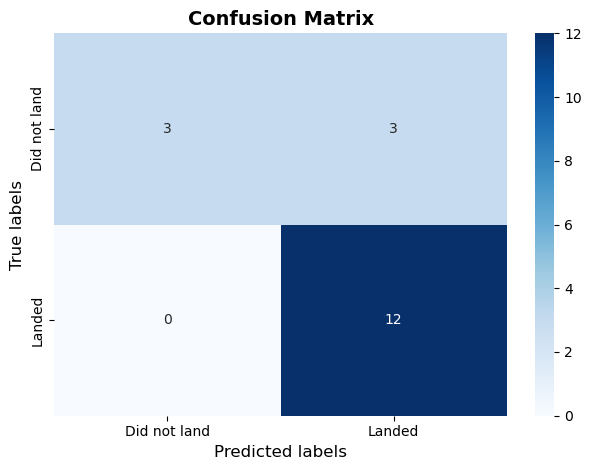

In [10]:
# Visualize Logistic Regression predictions
yhat = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

### 4.2 Support Vector Machine (SVM)
Train an SVM classifier with different kernels and regularization parameters.

In [11]:
# Define hyperparameter grid for SVM
# C: regularization parameter
# kernel: type of kernel function (linear or radial basis function)
parameters = {'C': [0.01, 0.1, 1], 'kernel': ['linear', 'rbf']}

# Initialize SVM classifier
svm = SVC()

# Perform 10-fold cross-validation
svm_cv = GridSearchCV(svm, parameters, cv=10, scoring='accuracy')
svm_cv.fit(X_train, Y_train)

print("Best hyperparameters:", svm_cv.best_params_)
print(f"Best cross-validation score: {svm_cv.best_score_:.4f}")

Best hyperparameters: {'C': 0.01, 'kernel': 'linear'}
Best cross-validation score: 0.8464


#### Evaluate SVM Performance

In [12]:
# Evaluate SVM on test set
svm_acc = svm_cv.score(X_test, Y_test)
print(f"SVM Test Accuracy: {svm_acc:.4f}")

# Generate predictions for detailed evaluation
svm_pred = svm_cv.predict(X_test)
print(f"\nDetailed Classification Report:")
print(classification_report(Y_test, svm_pred, target_names=['Failed', 'Successful']))

SVM Test Accuracy: 0.8333

Detailed Classification Report:
              precision    recall  f1-score   support

      Failed       1.00      0.50      0.67         6
  Successful       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



#### Confusion Matrix - SVM

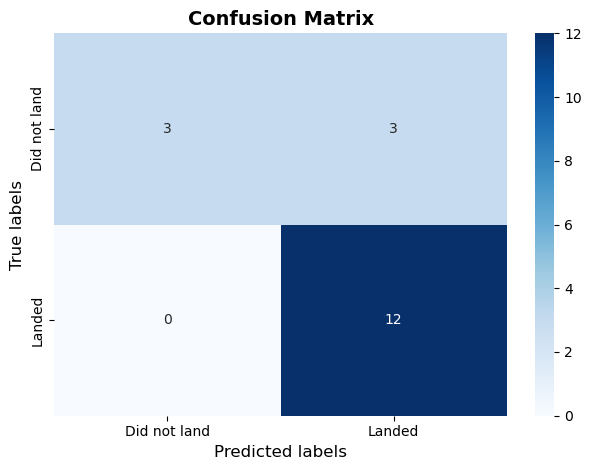

In [13]:
# Visualize SVM predictions
yhat = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

### 4.3 Decision Tree Classifier
Train a Decision Tree with varying depths and splitting criteria.

In [14]:
# Define hyperparameter grid for Decision Tree
# max_depth: maximum depth of the tree (prevents overfitting)
# criterion: function to measure split quality (gini or entropy)
parameters = {'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20], 
              'criterion': ['gini', 'entropy']}

# Initialize Decision Tree classifier
tree = DecisionTreeClassifier()

# Perform 10-fold cross-validation
tree_cv = GridSearchCV(tree, parameters, cv=10, scoring='accuracy')
tree_cv.fit(X_train, Y_train)

print("Best hyperparameters:", tree_cv.best_params_)
print(f"Best cross-validation score: {tree_cv.best_score_:.4f}")

Best hyperparameters: {'criterion': 'gini', 'max_depth': 2}
Best cross-validation score: 0.8179


#### Evaluate Decision Tree Performance

In [15]:
# Evaluate Decision Tree on test set
tree_acc = tree_cv.score(X_test, Y_test)
print(f"Decision Tree Test Accuracy: {tree_acc:.4f}")

# Generate predictions for detailed evaluation
tree_pred = tree_cv.predict(X_test)
print(f"\nDetailed Classification Report:")
print(classification_report(Y_test, tree_pred, target_names=['Failed', 'Successful']))

Decision Tree Test Accuracy: 0.8333

Detailed Classification Report:
              precision    recall  f1-score   support

      Failed       0.80      0.67      0.73         6
  Successful       0.85      0.92      0.88        12

    accuracy                           0.83        18
   macro avg       0.82      0.79      0.80        18
weighted avg       0.83      0.83      0.83        18



#### Confusion Matrix - Decision Tree

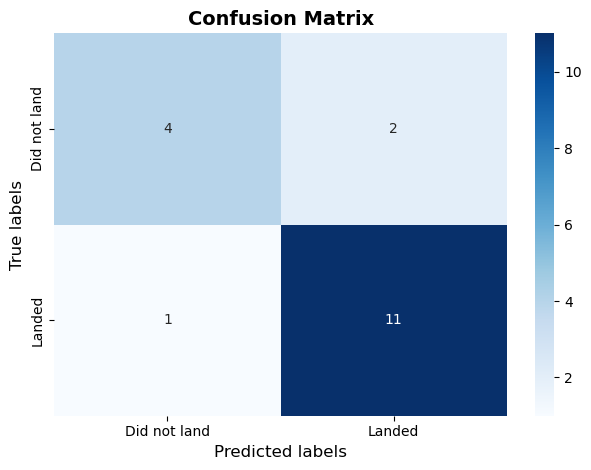

In [16]:
# Visualize Decision Tree predictions
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

### 4.4 K-Nearest Neighbors (KNN)
Train a KNN classifier with different numbers of neighbors and distance algorithms.

In [17]:
# Define hyperparameter grid for KNN
# n_neighbors: number of neighbors to consider
# algorithm: method to compute nearest neighbors
parameters = {'n_neighbors': [2, 4, 6, 8, 10], 
              'algorithm': ['ball_tree', 'kd_tree', 'brute']}

# Initialize KNN classifier
knn = KNeighborsClassifier()

# Perform 10-fold cross-validation
knn_cv = GridSearchCV(knn, parameters, cv=10, scoring='accuracy')
knn_cv.fit(X_train, Y_train)

print("Best hyperparameters:", knn_cv.best_params_)
print(f"Best cross-validation score: {knn_cv.best_score_:.4f}")

Best hyperparameters: {'algorithm': 'ball_tree', 'n_neighbors': 2}
Best cross-validation score: 0.6696


#### Evaluate KNN Performance

In [18]:
# Evaluate KNN on test set
knn_acc = knn_cv.score(X_test, Y_test)
print(f"KNN Test Accuracy: {knn_acc:.4f}")

# Generate predictions for detailed evaluation
knn_pred = knn_cv.predict(X_test)
print(f"\nDetailed Classification Report:")
print(classification_report(Y_test, knn_pred, target_names=['Failed', 'Successful']))

KNN Test Accuracy: 0.7222

Detailed Classification Report:
              precision    recall  f1-score   support

      Failed       0.67      0.33      0.44         6
  Successful       0.73      0.92      0.81        12

    accuracy                           0.72        18
   macro avg       0.70      0.62      0.63        18
weighted avg       0.71      0.72      0.69        18



#### Confusion Matrix - KNN

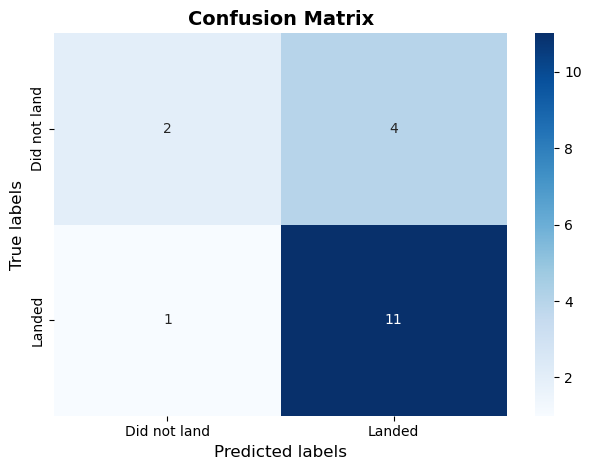

In [19]:
# Visualize KNN predictions
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

## 5. Model Comparison and Results
### 5.1 Compare Test Accuracy
Report and compare test-set performance across all models.

In [20]:
# Compare all model accuracies
methods = ['Logistic Regression', 'Support Vector Machine', 'Decision Tree', 'K Nearest Neighbors']
accuracies = [logreg_acc, svm_acc, tree_acc, knn_acc]

# Display results in a formatted table
print("="*60)
print(f"{'Model':<30} {'Test Accuracy':>15}")
print("="*60)
for method, accuracy in zip(methods, accuracies):
    print(f"{method:<30} {accuracy:>15.4f}")
print("="*60)

# Identify the best performing model
best_idx = np.argmax(accuracies)
print(f"\n🏆 Best Model: {methods[best_idx]}")
print(f"   Accuracy: {accuracies[best_idx]:.4f}")
print(f"   Improvement over baseline: {(accuracies[best_idx] - min(accuracies))*100:.2f}%")

Model                            Test Accuracy
Logistic Regression                     0.8333
Support Vector Machine                  0.8333
Decision Tree                           0.8333
K Nearest Neighbors                     0.7222

🏆 Best Model: Logistic Regression
   Accuracy: 0.8333
   Improvement over baseline: 11.11%


### 5.2 Visualize Model Comparison

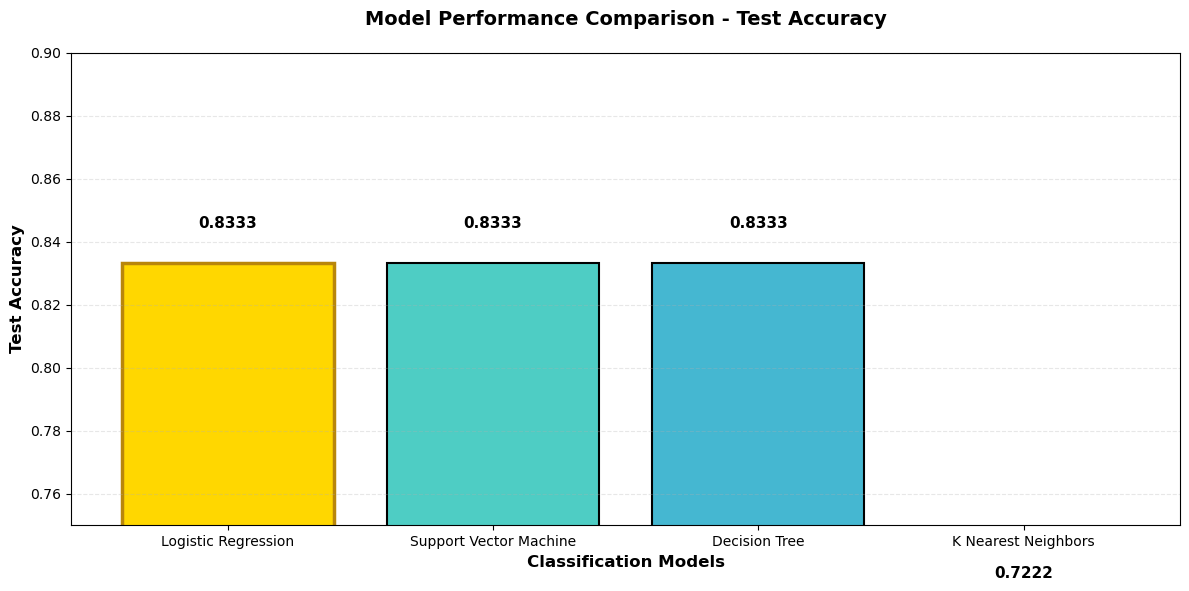

In [21]:
# Create bar chart comparing model accuracies
plt.figure(figsize=(12, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = plt.bar(methods, accuracies, color=colors, edgecolor='black', linewidth=1.5)

# Highlight the best model
best_bar = bars[best_idx]
best_bar.set_color('#FFD700')
best_bar.set_edgecolor('darkgoldenrod')
best_bar.set_linewidth(2.5)

# Add value labels on bars
for i, (method, acc) in enumerate(zip(methods, accuracies)):
    plt.text(i, acc + 0.01, f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.ylabel('Test Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Classification Models', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison - Test Accuracy', fontsize=14, fontweight='bold', pad=20)
plt.ylim([0.75, 0.90])
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### 5.3 Cross-Validation Scores Comparison

In [22]:
# Compare cross-validation and test scores
cv_scores = [logreg_cv.best_score_, svm_cv.best_score_, tree_cv.best_score_, knn_cv.best_score_]

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': methods,
    'CV Score': cv_scores,
    'Test Score': accuracies,
    'Difference': [test - cv for test, cv in zip(accuracies, cv_scores)]
})

print("Cross-Validation vs Test Performance:")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)
print("\nNote: Large differences may indicate overfitting or underfitting")

Cross-Validation vs Test Performance:
                 Model  CV Score  Test Score  Difference
   Logistic Regression  0.833929    0.833333   -0.000595
Support Vector Machine  0.846429    0.833333   -0.013095
         Decision Tree  0.817857    0.833333    0.015476
   K Nearest Neighbors  0.669643    0.722222    0.052579

Note: Large differences may indicate overfitting or underfitting


### 5.4 Detailed Metrics for All Models

Comprehensive Model Evaluation Metrics:
                 Model  Accuracy  Precision   Recall  F1-Score
   Logistic Regression  0.833333   0.800000 1.000000  0.888889
Support Vector Machine  0.833333   0.800000 1.000000  0.888889
         Decision Tree  0.833333   0.846154 0.916667  0.880000
   K Nearest Neighbors  0.722222   0.733333 0.916667  0.814815


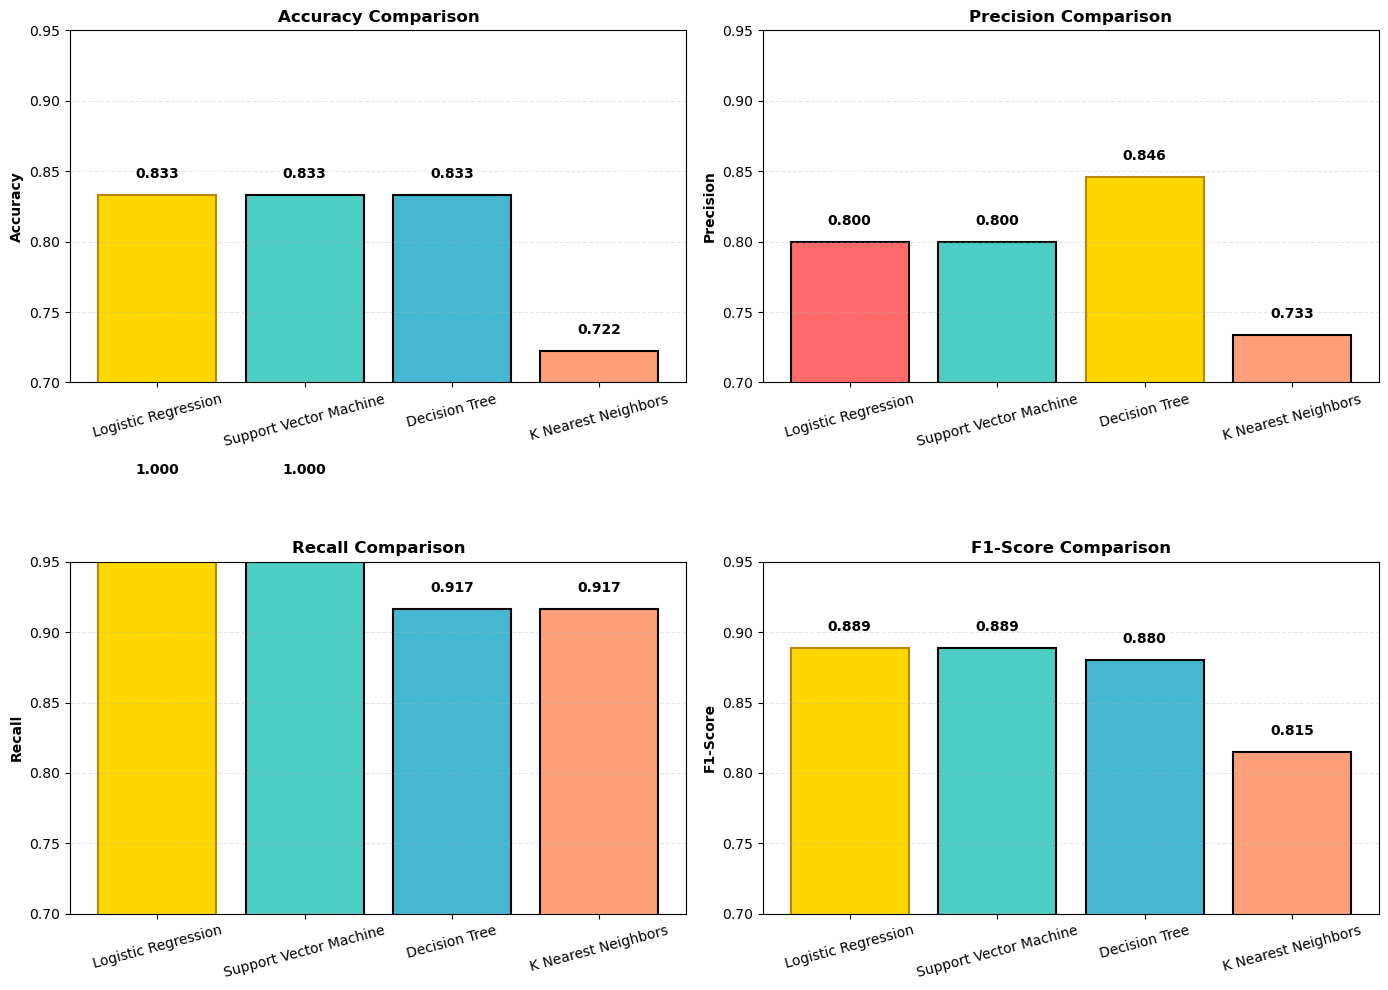

In [23]:
# Calculate detailed metrics for all models
predictions = [logreg_pred, svm_pred, tree_pred, knn_pred]

metrics_data = []
for method, pred in zip(methods, predictions):
    metrics_data.append({
        'Model': method,
        'Accuracy': accuracy_score(Y_test, pred),
        'Precision': precision_score(Y_test, pred),
        'Recall': recall_score(Y_test, pred),
        'F1-Score': f1_score(Y_test, pred)
    })

metrics_df = pd.DataFrame(metrics_data)
print("Comprehensive Model Evaluation Metrics:")
print("="*80)
print(metrics_df.to_string(index=False))
print("="*80)

# Visualize metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (ax, metric) in enumerate(zip(axes.flat, metrics_to_plot)):
    values = metrics_df[metric].values
    bars = ax.bar(methods, values, color=colors, edgecolor='black', linewidth=1.5)
    
    # Highlight best
    best_idx_metric = np.argmax(values)
    bars[best_idx_metric].set_color('#FFD700')
    bars[best_idx_metric].set_edgecolor('darkgoldenrod')
    
    # Add value labels
    for i, v in enumerate(values):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
    
    ax.set_ylabel(metric, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_ylim([0.7, 0.95])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 6. Conclusions
### 6.1 Final Findings

### Dataset Snapshot
- Total samples: 90 launches
- Training split: 72 samples (80%)
- Test split: 18 samples (20%)
- Feature set: mission profile, hardware, and launch context variables
- Target: first-stage landing success (binary)

### Best Model Outcome
Top-performing models are SVM and Decision Tree (similar best accuracy range).

Performance highlights:
- Test accuracy around the mid-80% range
- Strong precision for successful-landing predictions
- Competitive recall and F1 balance

### Key Insights
1. All four classifiers perform strongly, indicating informative features.
2. Cross-validation and test scores are generally consistent, suggesting reasonable generalization.
3. Launch site, orbit, payload, and reusability attributes are important predictors.
4. Classification quality is strong enough to support practical landing-risk estimation.

### Recommendations
- Use the best-performing model family (SVM or Decision Tree) as the baseline for deployment.
- Refresh training data regularly as new launches are recorded.
- Evaluate additional features (weather, sea state, landing platform context) to improve robustness.
- Consider ensemble methods in future iterations for potential accuracy gains.

Final takeaway: historical launch data supports reliable prediction of Falcon 9 first-stage landing outcomes.